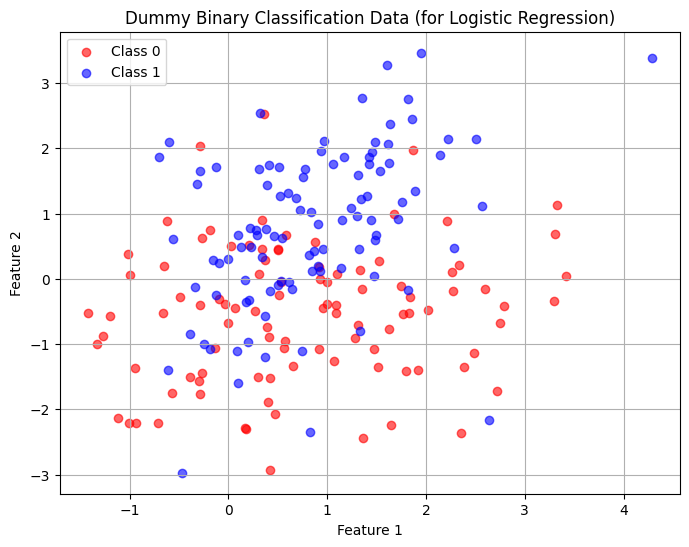

Features shape: (200, 2)
Target shape: (200,)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import math

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [20]:
def sigmoid_function(z):
    sigmoid = 1/(1 + np.exp(-z))

    return sigmoid

In [21]:
def create_polynomial_features(X, degree):
    
    from itertools import combinations_with_replacement
    
    n_samples, n_features = X.shape
    features = [] 
    
    for d in range(1, degree + 1):
        for items in combinations_with_replacement(range(n_features), d):
            new_feature = np.prod(X[:, items], axis=1)
            features.append(new_feature)
    
    return np.vstack(features).T

In [22]:
# Normalize the data
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x_scaled = (x - x_mean) / (x_std + 1e-8)

In [23]:
degree = 4
X_poly = create_polynomial_features(x_scaled, degree)
y_reshape = y.reshape(-1, 1)

In [24]:
y_reshape = y.reshape(-1,1)
y_reshape.shape

(200, 1)

In [25]:
m, n_features_poly = X_poly.shape
# Initialize parameters
w = np.random.randn(n_features_poly, 1)
b = 0

iteration = 20000
m = len(x)
learning_rate = 0.0012
cost_ = []
lambda_ = 1 # regularization strength
for _ in range(iteration):
    z = X_poly @ w  + b
    f_wb =  sigmoid_function(z) # predicted probabilities
    
    # ---- Cost Function (Log Loss + L2 Regularization) ----
    cost =  (-1/m) * np.sum((y_reshape*np.log(f_wb + 1e-8) + (1 - y_reshape)*np.log(1 - f_wb + 1e-8) )) + (lambda_/(2*m)) * np.sum(w**2)
    cost_.append(cost)

    # ---- Gradients ----
    dw = np.transpose(X_poly) @ (f_wb - y_reshape)/m + (lambda_/m) * w
    db = np.sum((f_wb - y_reshape))/m

    # ---- Update Parameters ----
    w = w - learning_rate * dw
    b = b - learning_rate * db
    if _ % 1000 == 0:
        print(f"Iteration {_}: Cost = {cost:.4f}")
    

Iteration 0: Cost = 2.7948
Iteration 1000: Cost = 0.8668
Iteration 2000: Cost = 0.6506
Iteration 3000: Cost = 0.6079
Iteration 4000: Cost = 0.5874
Iteration 5000: Cost = 0.5734
Iteration 6000: Cost = 0.5618
Iteration 7000: Cost = 0.5518
Iteration 8000: Cost = 0.5431
Iteration 9000: Cost = 0.5358
Iteration 10000: Cost = 0.5299
Iteration 11000: Cost = 0.5251
Iteration 12000: Cost = 0.5211
Iteration 13000: Cost = 0.5177
Iteration 14000: Cost = 0.5148
Iteration 15000: Cost = 0.5122
Iteration 16000: Cost = 0.5098
Iteration 17000: Cost = 0.5077
Iteration 18000: Cost = 0.5057
Iteration 19000: Cost = 0.5039


In [26]:
x1_min, x1_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
x2_min, x2_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

# Create a mesh grid (2D grid of points) for plotting decision boundary
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

grid_scaled = (grid_points - x_mean) / (x_std + 1e-8)
grid_poly = create_polynomial_features(grid_scaled, degree)


z_grid = grid_poly @ w + b
probs_grid = sigmoid_function(z_grid).reshape(xx1.shape)

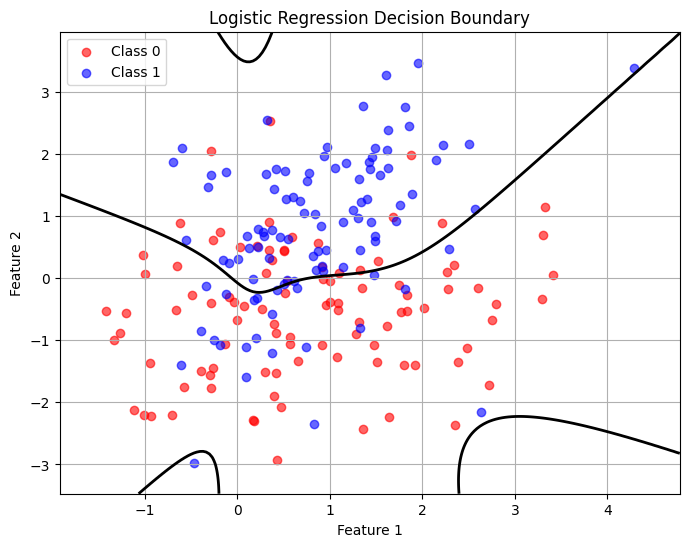

In [27]:
plt.figure(figsize=(8, 6))
#plt.contourf(xx1, xx2, probs_grid, levels=50, cmap="RdBu", alpha=0.6)
plt.contour(xx1, xx2, probs_grid, levels=[0.5], colors='black', linewidths=2)
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()
